#Instal Library


In [2]:
!pip install pmdarima
import pandas as pd
import datetime
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet
from prophet.plot import plot_plotly
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.ar_model import AutoReg,ARResults
nlag = 40
from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 31.4 MB/s eta 0:00:00


#Read Data

In [3]:
df = pd.read_excel("https://raw.githubusercontent.com/dzulfi02/BLKPP-Data-Analis/main/Forecasting-Time-Series/Dataset/data_harga_ayam.xlsx")

In [4]:
df.head()

,Tanggal,Komoditas,Harga
0,01/ 07/ 2022,Daging Ayam Segar,"36,900"
1,04/ 07/ 2022,Daging Ayam Segar,"36,750"
2,05/ 07/ 2022,Daging Ayam Segar,"36,750"
3,06/ 07/ 2022,Daging Ayam Segar,"36,850"
4,07/ 07/ 2022,Daging Ayam Segar,"37,150"


Dataset merupakan data harga daging ayam segar di Indonesia yang diambil dari website Pusat Informasi Harga Pangan Strategi Nasiona (PIHPS) dari periode Periode	: 1 Jul 2022 - 10 Jul 2026
adapun link sebagai berikut :  https://www.bi.go.id/hargapangan/TabelHarga/PasarTradisionalDaerah

#EDA Awal

##Informasi Dataset


In [5]:
df.shape

(1051, 3)

In [6]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Jumlah baris : 1051
Jumlah kolom : 3


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1051 entries, 0 to 1050
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tanggal    1051 non-null   object
 1   Komoditas  1051 non-null   object
 2   Harga      1051 non-null   object
dtypes: object(3)
memory usage: 24.8+ KB


##Ubah Tipe Data

In [8]:
df["Tanggal"] = pd.to_datetime(df["Tanggal"], format="%d/ %m/ %Y")

In [9]:
df["Harga"] = (
    df["Harga"]
      .astype(str)
      .str.replace(",", "")
      .replace("-", pd.NA)
      .astype(float)
)

In [10]:
df.rename(columns={"Harga": "Harga (Rp)"}, inplace=True)

In [11]:
df["Harga (Rp)"] = df["Harga (Rp)"].astype(int)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1051 entries, 0 to 1050
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Tanggal     1051 non-null   datetime64[ns]
 1   Komoditas   1051 non-null   object        
 2   Harga (Rp)  1051 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 24.8+ KB


In [13]:
df.head()

,Tanggal,Komoditas,Harga (Rp)
0,2022-07-01,Daging Ayam Segar,36900
1,2022-07-04,Daging Ayam Segar,36750
2,2022-07-05,Daging Ayam Segar,36750
3,2022-07-06,Daging Ayam Segar,36850
4,2022-07-07,Daging Ayam Segar,37150


##Missing Value

In [14]:
df.isnull().sum()

,0
Tanggal,0
Komoditas,0
Harga (Rp),0


##Duplicate Data

In [15]:
df.duplicated().sum()

np.int64(0)

##Statistik Deskriptif

In [16]:
df.describe()

,Tanggal,Harga (Rp)
count,1051,1051.000000
mean,2024-07-05 19:10:54.234062848,37101.617507
min,2022-07-01 00:00:00,30700.000000
25%,2023-07-04 12:00:00,35450.000000
50%,2024-07-05 00:00:00,36750.000000
75%,2025-07-08 12:00:00,38600.000000
max,2026-07-10 00:00:00,43900.000000
std,NaN,2153.792281


##Visualisasi Data Historis

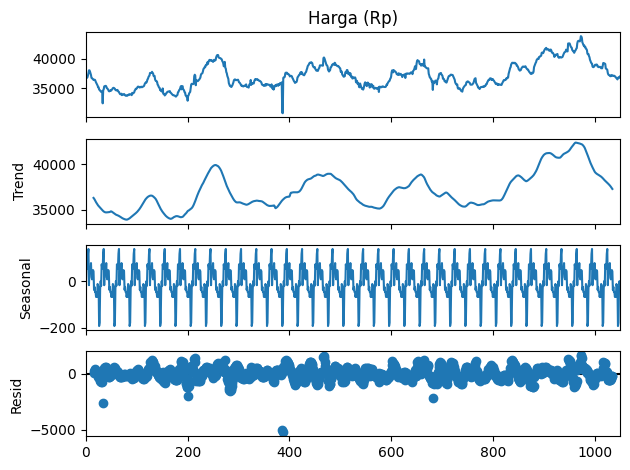

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose = seasonal_decompose(
    df["Harga (Rp)"],
    model="additive",
    period=30
)

decompose.plot()
plt.show()

Berdasarkan hasil eksplorasi data, dataset harga ayam memiliki pola fluktuatif dengan rentang harga sekitar Rp32.000–Rp44.000 selama periode Juli 2022 hingga Juli 2026. Visualisasi Moving Average 30 hari menunjukkan adanya tren kenaikan harga pada akhir tahun 2025 hingga awal tahun 2026 sebelum kembali menurun. Selain itu, analisis rata-rata harga bulanan mengindikasikan adanya pola musiman, meskipun diperlukan pengujian lebih lanjut untuk memastikan signifikansi pola tersebut. Secara keseluruhan, dataset telah menunjukkan karakteristik yang sesuai untuk dilakukan pemodelan forecasting time series.

#Data Processing

##Parsing Format Tanggal

In [18]:
df["Tanggal"] = pd.to_datetime(df["Tanggal"])

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1051 entries, 0 to 1050
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Tanggal     1051 non-null   datetime64[ns]
 1   Komoditas   1051 non-null   object        
 2   Harga (Rp)  1051 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 24.8+ KB


##Sort Berdasarkan Waktu

In [20]:
df = df.sort_values("Tanggal")
df.reset_index(drop=True, inplace=True)

##Feature Datetime

In [21]:
df["Tahun"] = df["Tanggal"].dt.year
df["Bulan"] = df["Tanggal"].dt.month
hari_dict = {
    "Monday": "Senin",
    "Tuesday": "Selasa",
    "Wednesday": "Rabu",
    "Thursday": "Kamis",
    "Friday": "Jumat",
    "Saturday": "Sabtu",
    "Sunday": "Minggu"
}
df["Hari"] = df["Tanggal"].dt.day_name().map(hari_dict)
df["Minggu ke"] = df["Tanggal"].dt.dayofweek

In [22]:
df

,Tanggal,Komoditas,Harga (Rp),Tahun,Bulan,Hari,Minggu ke
0,2022-07-01,Daging Ayam Segar,36900,2022,7,Jumat,4
1,2022-07-04,Daging Ayam Segar,36750,2022,7,Senin,0
2,2022-07-05,Daging Ayam Segar,36750,2022,7,Selasa,1
3,2022-07-06,Daging Ayam Segar,36850,2022,7,Rabu,2
4,2022-07-07,Daging Ayam Segar,37150,2022,7,Kamis,3
...,...,...,...,...,...,...,...
1046,2026-07-06,Daging Ayam Segar,36700,2026,7,Senin,0
1047,2026-07-07,Daging Ayam Segar,36850,2026,7,Selasa,1
1048,2026-07-08,Daging Ayam Segar,36750,2026,7,Rabu,2
1049,2026-07-09,Daging Ayam Segar,36850,2026,7,Kamis,3


##Scaling

In [23]:
#from sklearn.preprocessing import MinMaxScaler

#scaler = MinMaxScaler()

#df["Harga_scaled"] = scaler.fit_transform(df[["Harga (Rp)"]])

jika menggunakan LSTM baru pake scalling



#EDA

##Grafik Time Series

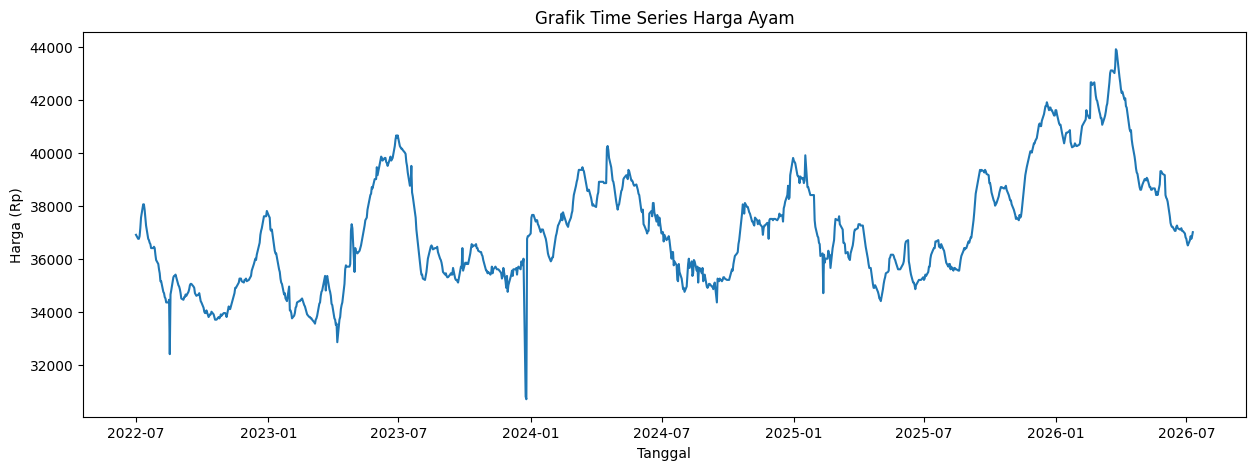

In [24]:
plt.figure(figsize=(15,5))

plt.plot(df["Tanggal"], df["Harga (Rp)"])

plt.title("Grafik Time Series Harga Ayam")
plt.xlabel("Tanggal")
plt.ylabel("Harga (Rp)")
plt.show()

Berdasarkan grafik historis, harga ayam selama periode Juli 2022 hingga Juli 2026 mengalami fluktuasi yang cukup dinamis dengan kisaran harga sekitar Rp32.000 hingga Rp44.000. Terlihat beberapa periode kenaikan dan penurunan harga, dengan harga tertinggi terjadi pada awal tahun 2026 sebelum kembali mengalami penurunan pada pertengahan tahun 2026.

##Distribusi Data

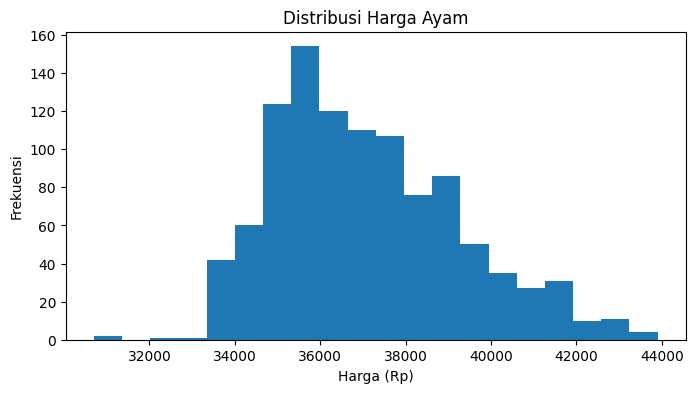

In [25]:
plt.figure(figsize=(8,4))

plt.hist(df["Harga (Rp)"], bins=20)

plt.title("Distribusi Harga Ayam")
plt.xlabel("Harga (Rp)")
plt.ylabel("Frekuensi")
plt.show()

Distribusi harga menunjukkan sebagian besar harga berada pada kisaran tertentu dengan beberapa nilai yang lebih tinggi atau lebih rendah. Hal ini memberikan gambaran mengenai persebaran harga selama periode pengamatan.

##Rolling Mean

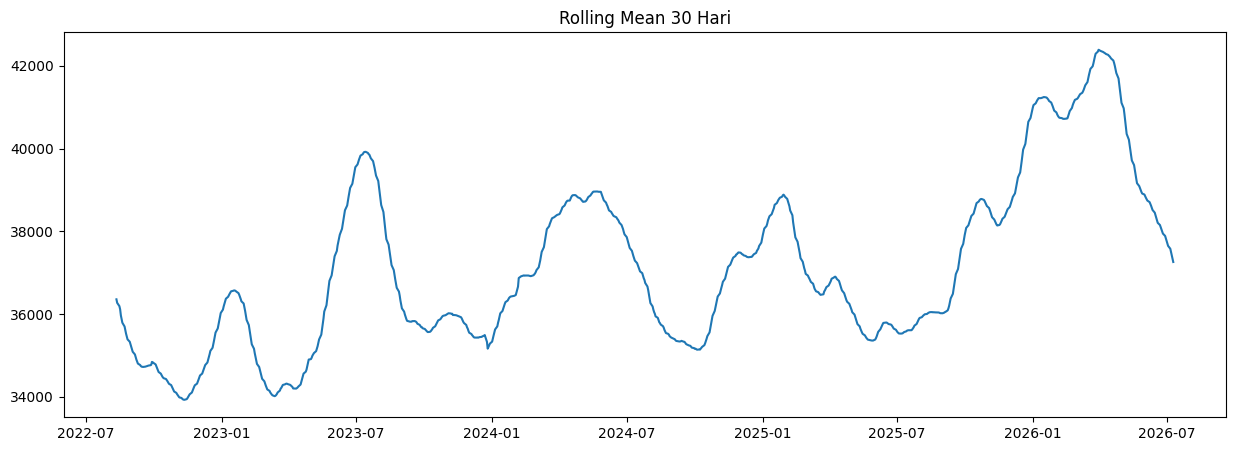

In [26]:
df["Rolling Mean"] = df["Harga (Rp)"].rolling(30).mean()

plt.figure(figsize=(15,5))

plt.plot(df["Tanggal"], df["Rolling Mean"])

plt.title("Rolling Mean 30 Hari")
plt.show()

Rolling Mean memperlihatkan rata-rata harga dalam 30 hari terakhir sehingga fluktuasi harian menjadi lebih halus dan tren harga lebih mudah diamati.

##Rolling Standard Deviation

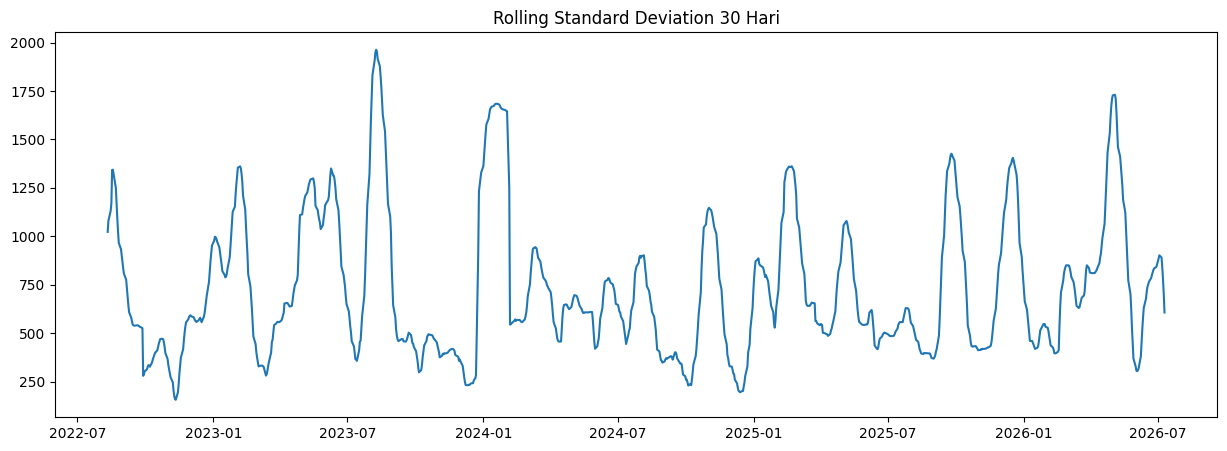

In [27]:
df["Rolling Std"] = df["Harga (Rp)"].rolling(30).std()

plt.figure(figsize=(15,5))

plt.plot(df["Tanggal"], df["Rolling Std"])

plt.title("Rolling Standard Deviation 30 Hari")
plt.show()

Rolling Standard Deviation menunjukkan tingkat variasi harga selama periode 30 hari. Nilai yang lebih tinggi mengindikasikan fluktuasi harga yang lebih besar dibandingkan periode lainnya.

##Analisis Trend

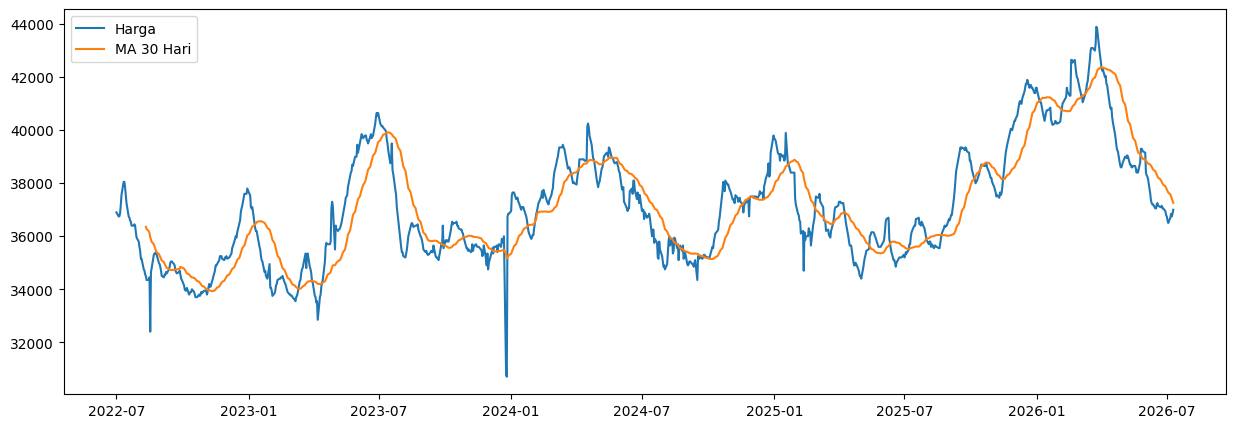

In [28]:
df["MA30"] = df["Harga (Rp)"].rolling(30).mean()

plt.figure(figsize=(15,5))

plt.plot(df["Tanggal"], df["Harga (Rp)"], label="Harga")
plt.plot(df["Tanggal"], df["MA30"], label="MA 30 Hari")

plt.legend()
plt.show()

Grafik Moving Average (MA) 30 hari menunjukkan tren harga yang lebih halus dibandingkan data harian. Terlihat bahwa harga ayam cenderung mengalami tren meningkat mulai pertengahan tahun 2025 hingga awal tahun 2026, kemudian berangsur menurun pada beberapa bulan berikutnya.

##Analisis Seasonality

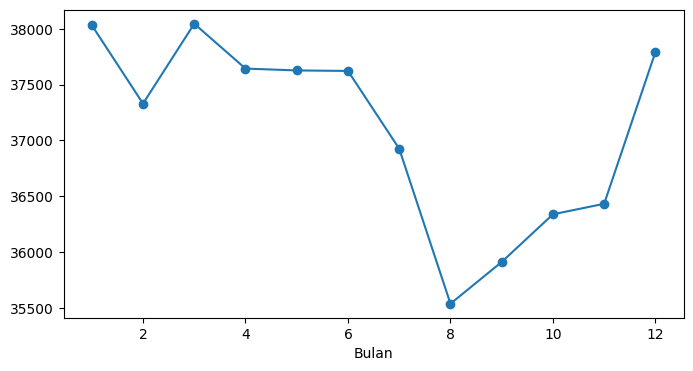

In [29]:
df["Bulan"] = df["Tanggal"].dt.month

bulan = df.groupby("Bulan")["Harga (Rp)"].mean()

plt.figure(figsize=(8,4))

bulan.plot(marker="o")

plt.show()

Berdasarkan rata-rata harga setiap bulan, terlihat bahwa harga ayam relatif lebih tinggi pada bulan Januari, Maret, dan Desember, sedangkan harga terendah terjadi pada sekitar bulan Agustus. Pola ini mengindikasikan adanya kemungkinan pengaruh faktor musiman terhadap perubahan harga ayam, meskipun diperlukan analisis lanjutan untuk memastikan adanya seasonality secara signifikan.

#Uji Stasioneritas (ADF Test)

In [30]:
def adf_test(series, name=""):
    result = adfuller(series.dropna())
    print(f"ADF Test - {name}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    if result[1] <= 0.05:
        print("  => Data stasioner (tolak H0)")
    else:
        print("  => Data TIDAK stasioner, perlu differencing (gagal tolak H0)")
    return result[1]


adf_test(df["Harga (Rp)"], name="Harga (Rp) - level")
adf_test(df["Harga (Rp)"].diff(), name="Harga (Rp) - differencing 1x")

ADF Test - Harga (Rp) - level
  ADF Statistic : -2.8688
  p-value       : 0.0491
  => Data stasioner (tolak H0)
ADF Test - Harga (Rp) - differencing 1x
  ADF Statistic : -13.3315
  p-value       : 0.0000
  => Data stasioner (tolak H0)


np.float64(6.170074233581089e-25)

#Modeling


##Split Data

In [31]:
df = df.set_index("Tanggal")

# set frequency eksplisit ke "B" (business day) karena data historis
# ternyata memang hanya tersedia di hari kerja (Senin-Jumat), tanpa tanggal bolong.
df = df.asfreq("B")
df["Harga (Rp)"] = df["Harga (Rp)"].interpolate(method="linear")  # jaga-jaga jika asfreq membuat NaN baru

In [32]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Jumlah Data Train :", len(train))
print("Jumlah Data Test :", len(test))

Jumlah Data Train : 840
Jumlah Data Test : 211


##ARIMA

In [33]:
auto_model_arima = auto_arima(
    train["Harga (Rp)"],
    seasonal=False,
    trace=True,
    stepwise=True,
    suppress_warnings=True
)

print(auto_model_arima.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=12411.330, Time=1.17 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=12425.352, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=12425.418, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=12424.748, Time=0.34 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=12423.396, Time=0.08 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=12411.068, Time=0.47 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=12411.771, Time=0.72 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=12423.018, Time=0.39 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=12405.071, Time=1.00 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=12408.671, Time=0.69 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=12405.613, Time=1.20 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=12406.392, Time=0.97 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=12407.238, Time=0.45 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=12403.000, Time=3.51 sec
 ARIMA(3,1,4)(0,0,0

In [34]:
order_arima = auto_model_arima.order
print("Order ARIMA terpilih (auto_arima):", order_arima)

Order ARIMA terpilih (auto_arima): (3, 1, 5)


In [35]:
arima_model = ARIMA(train["Harga (Rp)"], order=order_arima)
arima_fit = arima_model.fit()

In [36]:
forecast_arima = arima_fit.forecast(
    steps=len(test)
)

# Samakan index forecast dengan data test
forecast_arima.index = test.index

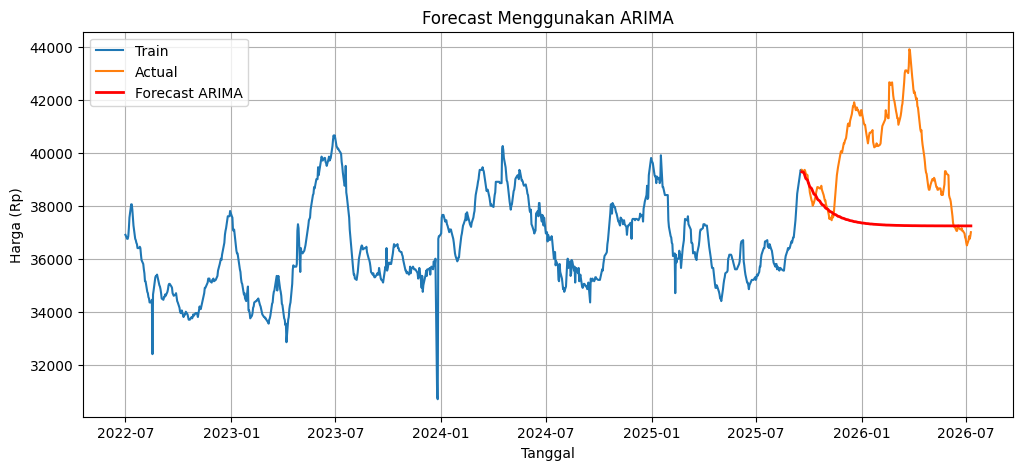

In [37]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train["Harga (Rp)"], label="Train")
plt.plot(test.index, test["Harga (Rp)"], label="Actual")
plt.plot(forecast_arima.index, forecast_arima, linewidth=2, color="red", label="Forecast ARIMA")
plt.title("Forecast Menggunakan ARIMA")
plt.xlabel("Tanggal")
plt.ylabel("Harga (Rp)")
plt.legend()
plt.grid(True)
plt.show()

##SARIMA

In [38]:
auto_model_sarima = auto_arima(
    train["Harga (Rp)"],
    seasonal=True,
    m=7,
    trace=True,
    stepwise=True,
    suppress_warnings=True,
)
print(auto_model_sarima.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=12415.314, Time=0.61 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=12425.352, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=12427.414, Time=0.11 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=12426.744, Time=0.20 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=12423.396, Time=0.04 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=12413.309, Time=0.58 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=12411.330, Time=0.31 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=12413.310, Time=0.72 sec
 ARIMA(1,1,2)(0,0,0)[7] intercept   : AIC=12411.068, Time=0.61 sec
 ARIMA(1,1,2)(1,0,0)[7] intercept   : AIC=12413.048, Time=0.58 sec
 ARIMA(1,1,2)(0,0,1)[7] intercept   : AIC=12413.047, Time=0.54 sec
 ARIMA(1,1,2)(1,0,1)[7] intercept   : AIC=12415.053, Time=0.60 sec
 ARIMA(0,1,2)(0,0,0)[7] intercept   : AIC=12411.771, Time=0.24 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=12423.018, Time=0.16 sec
 ARIMA(1,1,3)(0,0,0

In [39]:
order_sarima = auto_model_sarima.order
seasonal_order_sarima = auto_model_sarima.seasonal_order
print("Order SARIMA terpilih      :", order_sarima)
print("Seasonal order SARIMA      :", seasonal_order_sarima)

Order SARIMA terpilih      : (3, 1, 5)
Seasonal order SARIMA      : (0, 0, 0, 7)


In [40]:
sarima_model = SARIMAX(
    train["Harga (Rp)"],
    order=order_sarima,
    seasonal_order=seasonal_order_sarima,
)
sarima_fit = sarima_model.fit(disp=False)

In [41]:
forecast_sarima = sarima_fit.forecast(
    steps=len(test)
)

forecast_sarima.index = test.index

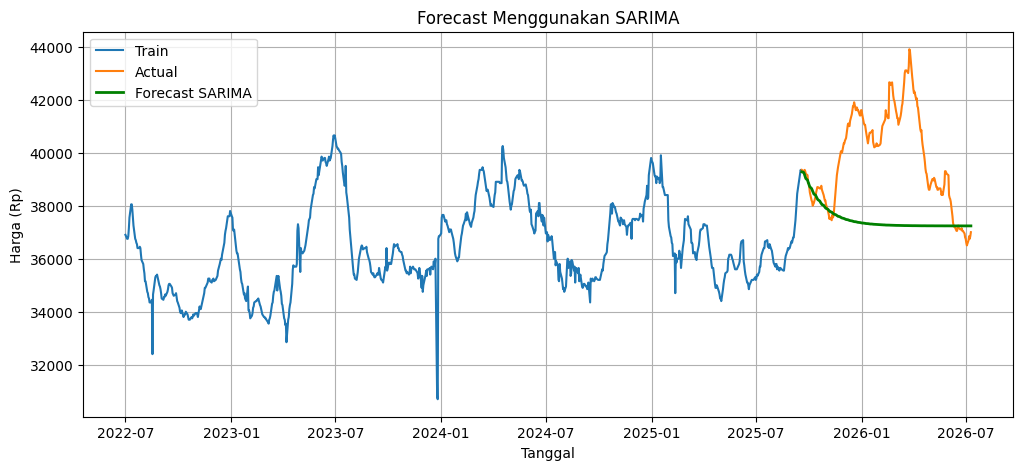

In [42]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train["Harga (Rp)"], label="Train")
plt.plot(test.index, test["Harga (Rp)"], label="Actual")
plt.plot(forecast_sarima.index, forecast_sarima, linewidth=2, color="green", label="Forecast SARIMA")
plt.title("Forecast Menggunakan SARIMA")
plt.xlabel("Tanggal")
plt.ylabel("Harga (Rp)")
plt.legend()
plt.grid(True)
plt.show()

##Holt Winter

In [43]:
hw_model = ExponentialSmoothing(
    train["Harga (Rp)"],
    trend="add",
    seasonal="add",
    seasonal_periods=7
)

hw_fit = hw_model.fit()

In [44]:
forecast_hw = hw_fit.forecast(
    len(test)
)

forecast_hw.index = test.index

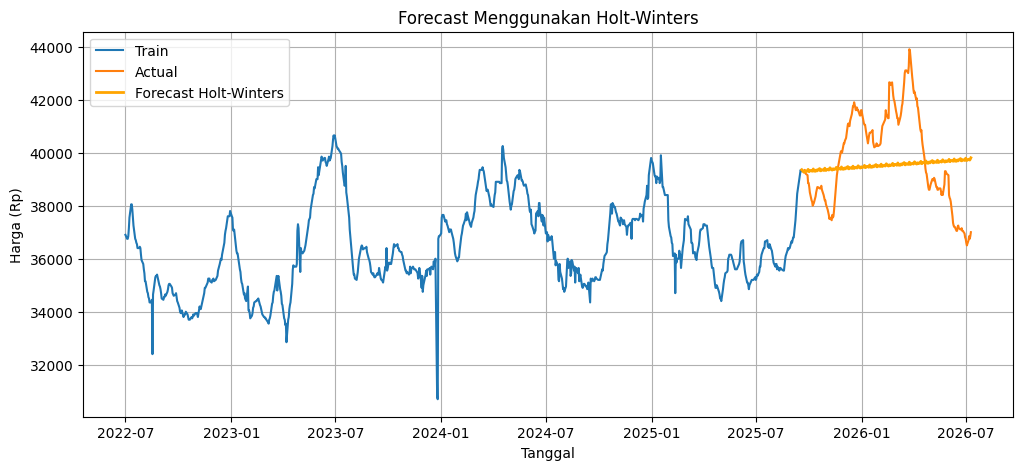

In [45]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train["Harga (Rp)"], label="Train")
plt.plot(test.index, test["Harga (Rp)"], label="Actual")
plt.plot(forecast_hw.index, forecast_hw, linewidth=2, color="orange", label="Forecast Holt-Winters")
plt.title("Forecast Menggunakan Holt-Winters")
plt.xlabel("Tanggal")
plt.ylabel("Harga (Rp)")
plt.legend()
plt.grid(True)
plt.show()

##Prophet

In [46]:
# Ubah train menjadi format Prophet
train_prophet = train.reset_index()[["Tanggal", "Harga (Rp)"]]
train_prophet.columns = ["ds", "y"]

In [47]:
# Membuat model
model = Prophet()

# Training
model.fit(train_prophet)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [48]:
# Membuat tanggal prediksi sebanyak data test
future = model.make_future_dataframe(
    periods=len(test),
    freq="B"
)

In [49]:
# Forecast
forecast = model.predict(future)

# Ambil hasil prediksi pada periode test
forecast_prophet = forecast.tail(len(test)).copy()

forecast_prophet.index = test.index

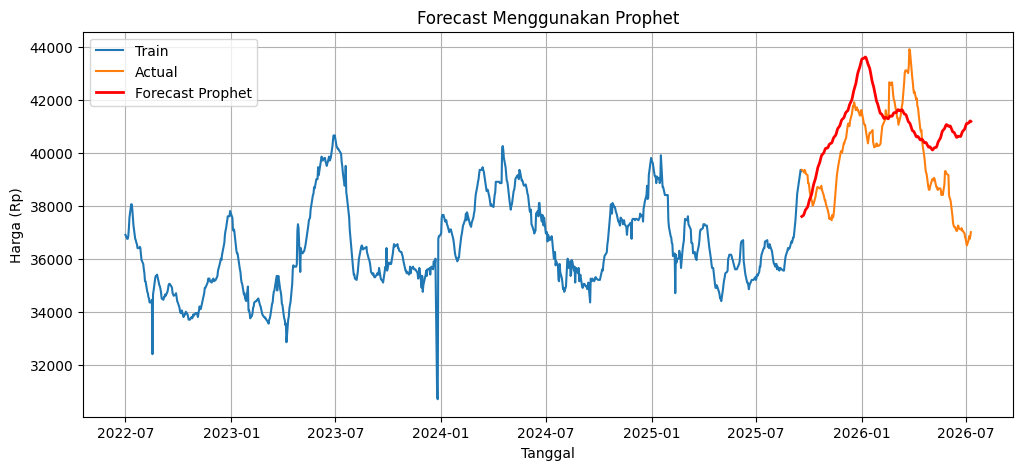

In [50]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train["Harga (Rp)"], label="Train")
plt.plot(test.index, test["Harga (Rp)"], label="Actual")
plt.plot(test.index, forecast_prophet["yhat"], color="red", linewidth=2, label="Forecast Prophet")
plt.title("Forecast Menggunakan Prophet")
plt.xlabel("Tanggal")
plt.ylabel("Harga (Rp)")
plt.legend()
plt.grid(True)
plt.show()

##Evaluasi Model

In [53]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return mae, rmse, mape


results = []
results.append(["ARIMA", *evaluate(test["Harga (Rp)"], forecast_arima)])
results.append(["SARIMA", *evaluate(test["Harga (Rp)"], forecast_sarima)])
results.append(["Holt Winter", *evaluate(test["Harga (Rp)"], forecast_hw)])
results.append(["Prophet", *evaluate(test["Harga (Rp)"], forecast_prophet["yhat"])])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "MAPE"]
).sort_values("RMSE").reset_index(drop=True)
results_df

,Model,MAE,RMSE,MAPE
0,Holt Winter,1589.870638,1851.212818,3.974525
1,Prophet,1666.012767,1993.543510,4.264582
2,SARIMA,2409.258957,3044.945201,5.860911
3,ARIMA,2409.258957,3044.945201,5.860911


##Grafik Perbandingan

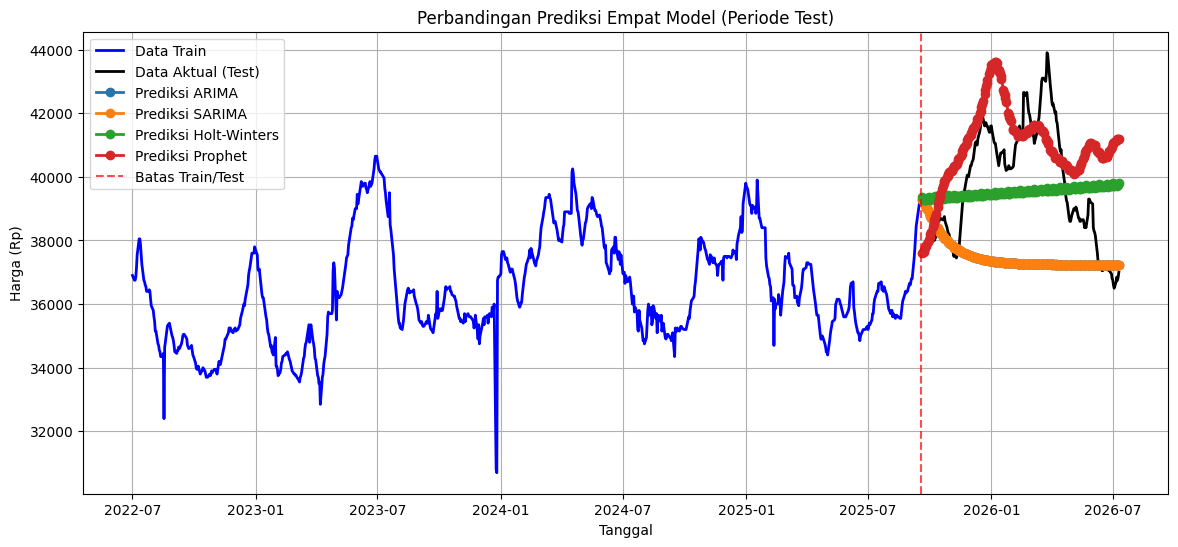

In [54]:
plt.figure(figsize=(14, 6))
plt.plot(train.index, train["Harga (Rp)"], color="blue", linewidth=2, label="Data Train")
plt.plot(test.index, test["Harga (Rp)"], color="black", linewidth=2, label="Data Aktual (Test)")
plt.plot(forecast_arima.index, forecast_arima.values, marker="o", linewidth=2, label="Prediksi ARIMA")
plt.plot(forecast_sarima.index, forecast_sarima.values, marker="o", linewidth=2, label="Prediksi SARIMA")
plt.plot(forecast_hw.index, forecast_hw.values, marker="o", linewidth=2, label="Prediksi Holt-Winters")
plt.plot(forecast_prophet.index, forecast_prophet["yhat"], marker="o", linewidth=2, label="Prediksi Prophet")
plt.axvline(train.index[-1], color="red", linestyle="--", alpha=0.7, label="Batas Train/Test")
plt.title("Perbandingan Prediksi Empat Model (Periode Test)")
plt.xlabel("Tanggal")
plt.ylabel("Harga (Rp)")
plt.legend()
plt.grid(True)
plt.show()

#Forecasting

In [55]:
print("Tabel evaluasi seluruh model (diurutkan berdasarkan RMSE):")
print(results_df)

best_model_name = "Holt Winter"  # dipilih langsung, harus persis sama dengan pengecekan di refit_and_forecast()
print(f"\nModel yang dipakai untuk forecasting: {best_model_name}")

Tabel evaluasi seluruh model (diurutkan berdasarkan RMSE):
         Model          MAE         RMSE      MAPE
0  Holt Winter  1589.870638  1851.212818  3.974525
1      Prophet  1666.012767  1993.543510  4.264582
2       SARIMA  2409.258957  3044.945201  5.860911
3        ARIMA  2409.258957  3044.945201  5.860911

Model yang dipakai untuk forecasting: Holt Winter


##Holt Winter

In [56]:
def refit_and_forecast(model_name, full_series, horizon,
                        order_arima=order_arima,
                        order_sarima=order_sarima,
                        seasonal_order_sarima=seasonal_order_sarima):
    """Retrain model terpilih dengan seluruh data dan forecast n hari ke depan (freq='B')."""
    future_index = pd.date_range(
        start=full_series.index[-1] + pd.offsets.BDay(1),
        periods=horizon,
        freq="B",
    )

    if model_name == "Holt Winter": # Changed from "Holt-Winters" to "Holt Winter"
        final_model = ExponentialSmoothing(
            full_series, trend="add", seasonal="add", seasonal_periods=7
        ).fit()
        pred = final_model.forecast(horizon)
        pred.index = future_index
        return pred, final_model

    raise ValueError(f"Model '{model_name}' tidak dikenali.")


full_series = df["Harga (Rp)"]

for horizon in (7, 14, 30):
    forecast_future, _ = refit_and_forecast(best_model_name, full_series, horizon)

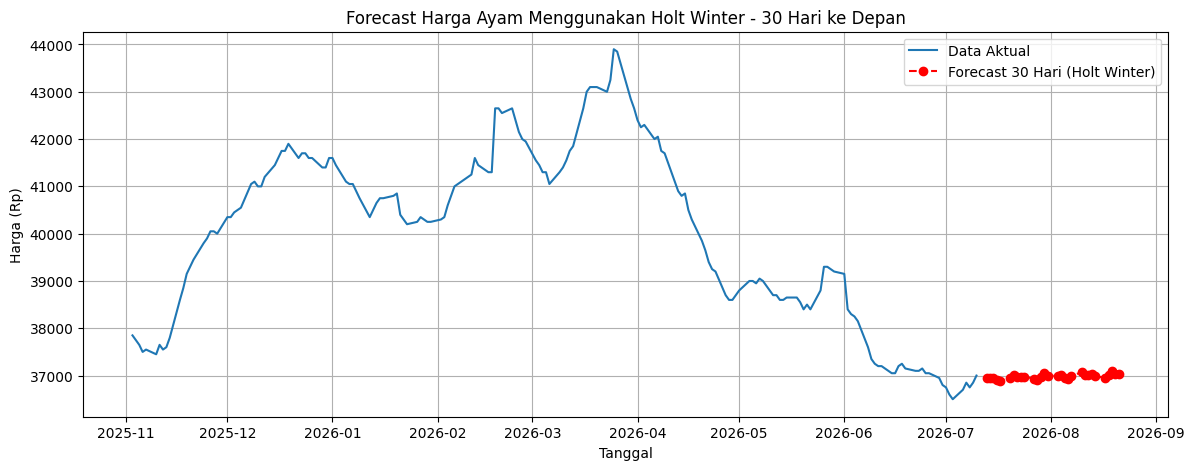


Nilai prediksi 30 hari ke depan (Holt Winter):
2026-07-13    36948
2026-07-14    36951
2026-07-15    36956
2026-07-16    36912
2026-07-17    36888
2026-07-20    36952
2026-07-21    37021
2026-07-22    36971
2026-07-23    36974
2026-07-24    36979
2026-07-27    36935
2026-07-28    36911
2026-07-29    36975
2026-07-30    37044
2026-07-31    36994
2026-08-03    36997
2026-08-04    37002
2026-08-05    36958
2026-08-06    36934
2026-08-07    36998
2026-08-10    37067
2026-08-11    37017
2026-08-12    37020
2026-08-13    37025
2026-08-14    36981
2026-08-17    36957
2026-08-18    37021
2026-08-19    37090
2026-08-20    37041
2026-08-21    37043
Freq: B, dtype: int64


In [57]:
    plt.figure(figsize=(14, 5))
    plt.plot(full_series.index[-180:], full_series.values[-180:], label="Data Aktual")
    plt.plot(forecast_future.index, forecast_future.values,
              label=f"Forecast {horizon} Hari ({best_model_name})",
              color="red", linestyle="--", marker="o")
    plt.title(f"Forecast Harga Ayam Menggunakan {best_model_name} - {horizon} Hari ke Depan")
    plt.xlabel("Tanggal")
    plt.ylabel("Harga (Rp)")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"\nNilai prediksi {horizon} hari ke depan ({best_model_name}):")
    print(forecast_future.round(0).astype(int))